Phase 5 — Trend Analysis Over Time
What we're building:

Visualizations showing how sentiment, topics, and review volume shifted from 1999–2012 — turning raw timestamps into business intelligence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Reviews_topics.csv')

# Convert Time to datetime if not already
df['Time'] = pd.to_datetime(df['Time'], unit='s', errors='coerce')
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

print(df.shape)
print(df['Year'].value_counts().sort_index())

(364163, 21)
Series([], Name: count, dtype: int64)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Reviews_topics.csv')

# Time is already a datetime string — just parse it directly
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Year'] = df['Time'].dt.year
df['Month'] = df['Time'].dt.month

print(df.shape)
print(df['Year'].value_counts().sort_index())

(364163, 21)
Year
1999         4
2000        17
2001         7
2002        33
2003        93
2004       431
2005      1023
2006      4482
2007     14869
2008     21624
2009     35191
2010     53848
2011    104333
2012    128208
Name: count, dtype: int64


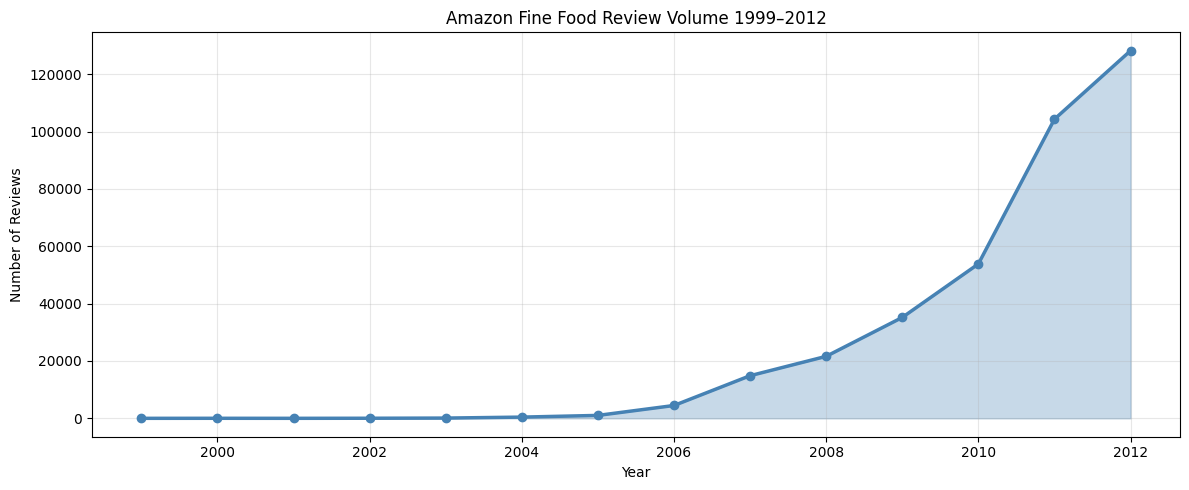

In [4]:
reviews_per_year = df.groupby('Year').size().reset_index(name='count')

plt.figure(figsize=(12, 5))
plt.plot(reviews_per_year['Year'], reviews_per_year['count'], 
         marker='o', color='steelblue', linewidth=2.5)
plt.fill_between(reviews_per_year['Year'], reviews_per_year['count'], 
                 alpha=0.3, color='steelblue')
plt.title('Amazon Fine Food Review Volume 1999–2012')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

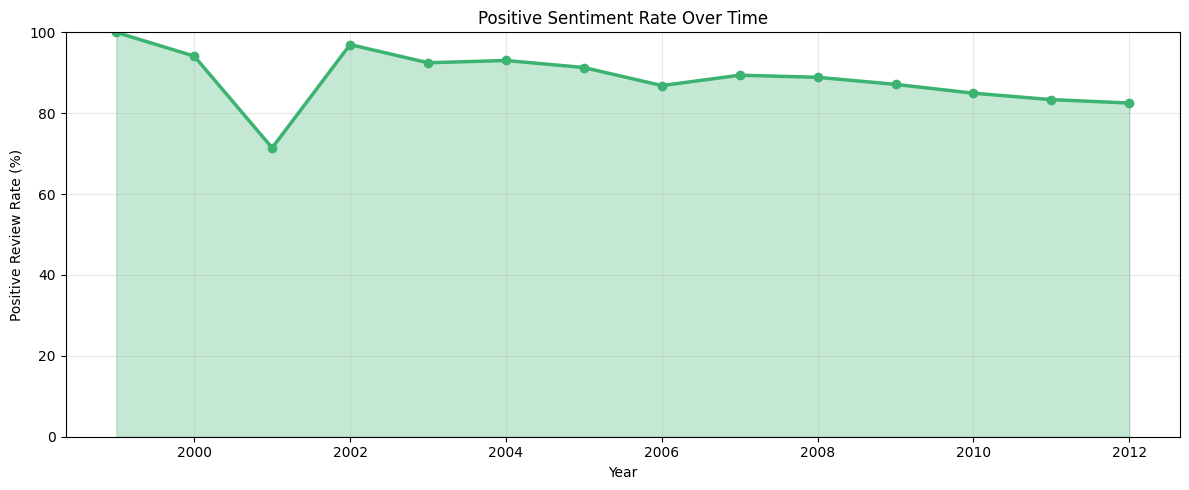

    Year  positive_rate
0   1999     100.000000
1   2000      94.117647
2   2001      71.428571
3   2002      96.969697
4   2003      92.473118
5   2004      93.039443
6   2005      91.300098
7   2006      86.836234
8   2007      89.394041
9   2008      88.882723
10  2009      87.130232
11  2010      84.948373
12  2011      83.360969
13  2012      82.518252


In [5]:
# Average sentiment per year
sentiment_by_year = df.groupby('Year')['sentiment'].agg(
    positive_rate=lambda x: (x == 1).mean() * 100
).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(sentiment_by_year['Year'], sentiment_by_year['positive_rate'],
         marker='o', color='mediumseagreen', linewidth=2.5)
plt.fill_between(sentiment_by_year['Year'], sentiment_by_year['positive_rate'],
                 alpha=0.3, color='mediumseagreen')
plt.title('Positive Sentiment Rate Over Time')
plt.xlabel('Year')
plt.ylabel('Positive Review Rate (%)')
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(sentiment_by_year)

What We See
Period            Sentiment                   Explanation
1999–2002      100% → 71% → 97%       Volatile — tiny sample size (only 4–33 reviews)
2003–2006        ~93% → 87%            First real decline as volume grew
2007–2012         89% → 82%               Steady gradual decline

The Business Insight

"Positive sentiment declined steadily from ~93% in 2003 to 82% in 2012 — inversely correlated with review volume growth. As Amazon's food marketplace expanded and attracted mainstream customers (not just early enthusiasts), satisfaction levels gradually declined — suggesting broader customer expectations were harder to meet at scale."

The early years (1999–2002) are statistically unreliable — only 4 to 33 reviews per year. The real trend starts from 2003 onwards.

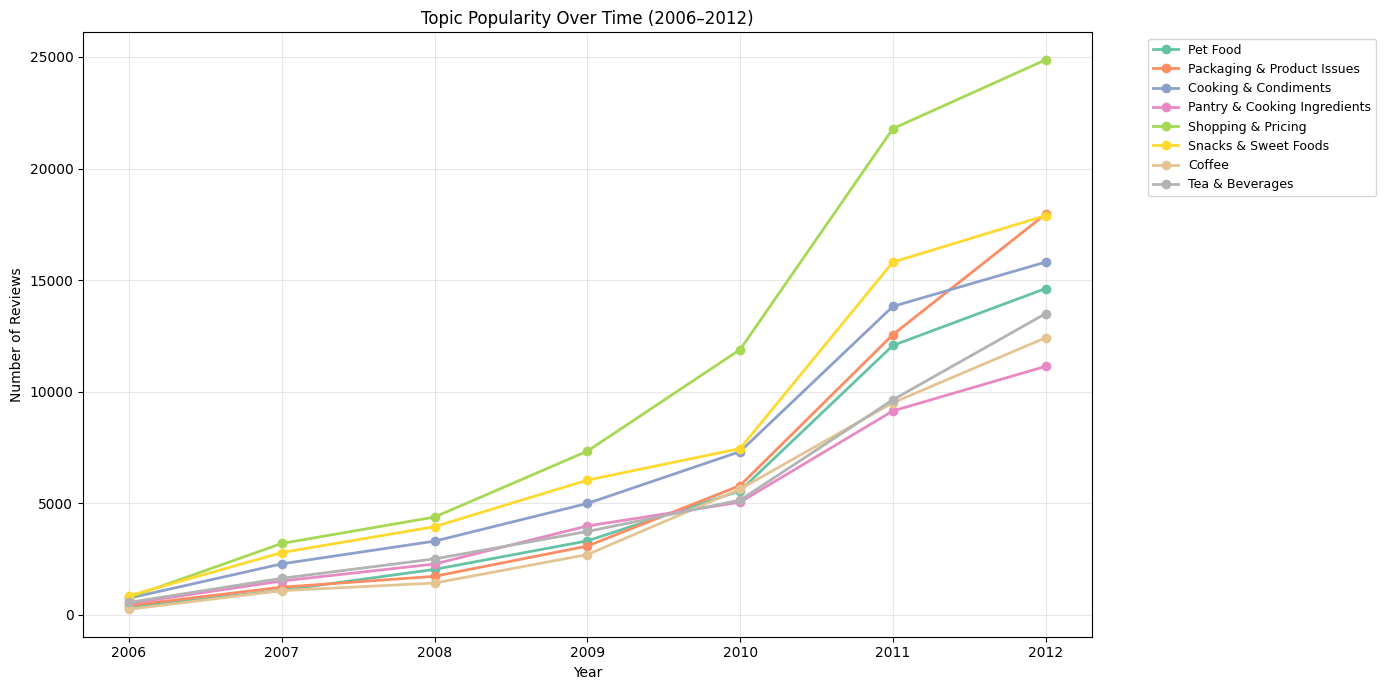

In [6]:
# Reviews per topic per year
topic_year = df.groupby(['Year', 'topic_label']).size().reset_index(name='count')

# Filter years with enough data
topic_year = topic_year[topic_year['Year'] >= 2006]

plt.figure(figsize=(14, 7))
topics = df['topic_label'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(topics)))

for i, topic in enumerate(topics):
    data = topic_year[topic_year['topic_label'] == topic]
    plt.plot(data['Year'], data['count'], 
             marker='o', label=topic, linewidth=2, color=colors[i])

plt.title('Topic Popularity Over Time (2006–2012)')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

What We See
Shopping & Pricing (green) — broke away from the pack in 2010
Every other topic grew together until 2010, then Shopping & Pricing suddenly accelerated far above the rest. This directly reflects Amazon's aggressive expansion of its food marketplace around that time.
Packaging & Product Issues (orange) — grew faster than most
Concerning signal — as volume grew, packaging complaints grew proportionally fast. It didn't slow down relative to other topics.☕ Coffee & Tea — consistently lowest volume
Niche but dedicated communities — small but likely highly engaged reviewers.


Business Insight

"Shopping & Pricing discussions grew disproportionately from 2010–2012 — outpacing all food categories — suggesting Amazon's food customers became increasingly price-sensitive as the platform scaled, likely driven by the introduction of Subscribe & Save and bulk buying options."


"Packaging complaints grew consistently alongside overall volume — indicating this was a structural operational issue rather than an isolated incident."

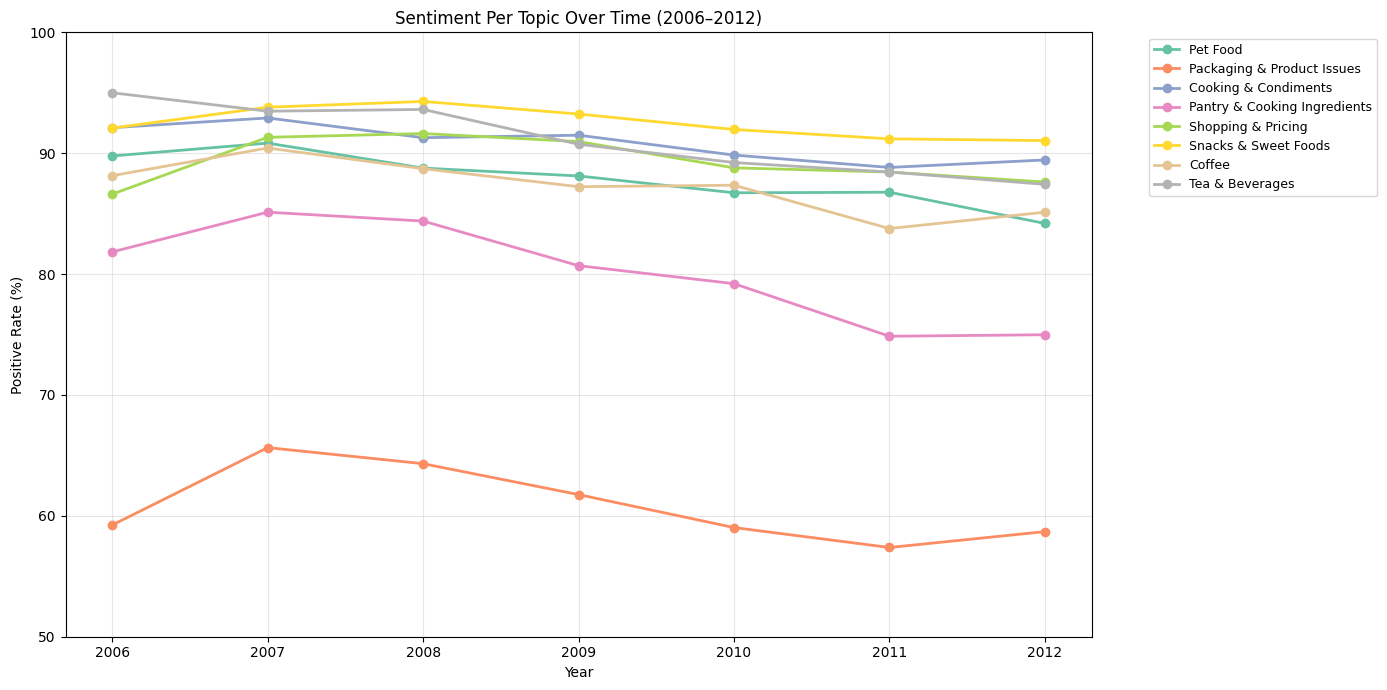

In [7]:
# Sentiment trend per topic over time
topic_sentiment_year = df[df['Year'] >= 2006].groupby(
    ['Year', 'topic_label']
)['sentiment'].mean().reset_index()
topic_sentiment_year['positive_rate'] = topic_sentiment_year['sentiment'] * 100

plt.figure(figsize=(14, 7))
for i, topic in enumerate(topics):
    data = topic_sentiment_year[topic_sentiment_year['topic_label'] == topic]
    plt.plot(data['Year'], data['positive_rate'],
             marker='o', label=topic, linewidth=2, color=colors[i])

plt.title('Sentiment Per Topic Over Time (2006–2012)')
plt.xlabel('Year')
plt.ylabel('Positive Rate (%)')
plt.ylim(50, 100)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


This is the most insightful chart in the entire project. Two lines immediately stand out:

What We See
Packaging & Product Issues — stuck at the bottom throughout
Never crossed 70% positive across all 7 years. This isn't a temporary problem — it's a chronic, unresolved issue from 2006 to 2012.
Pantry & Cooking Ingredients — dramatic decline
Started at 82% in 2006, crashed to 75% by 2011 — the steepest decline of any topic. Something got significantly worse in this category over time.
Snacks & Sweet Foods — most consistent
Stayed above 91% throughout — the most reliable category year after year.
Shopping & Pricing — surprisingly stable
Despite being the highest volume topic, sentiment stayed around 87–91% — customers were satisfied with pricing even as volume exploded.

Key Business Insights

"Packaging & Product Issues maintained consistently low sentiment (57–66%) throughout 2006–2012 — indicating a structural, long-term operational failure that was never resolved despite growing review volume."


"Pantry & Cooking Ingredients experienced the steepest sentiment decline of any category (-7% from 2006–2011) — suggesting deteriorating product quality or unmet customer expectations in everyday staple items."


"Snacks & Sweet Foods maintained the highest and most consistent satisfaction across all years — making it Amazon's most reliably positive food category."

In [8]:
# Save trend data
reviews_per_year = df.groupby('Year').size().reset_index(name='count')
reviews_per_year.to_csv('../outputs/reviews_per_year.csv', index=False)

sentiment_by_year.to_csv('../outputs/sentiment_by_year.csv', index=False)
topic_sentiment_year.to_csv('../outputs/topic_sentiment_year.csv', index=False)
topic_year.to_csv('../outputs/topic_year.csv', index=False)

print("All trend data saved successfully!")

All trend data saved successfully!
